In [2]:
from openai import OpenAI
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
import os

# Load OpenAI API key from .env file
load_dotenv()
client = OpenAI()


In [201]:
# Setting file paths
fold_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
train_data = json.load(open(os.path.join(fold_path, "ori_pqal.json")))
# dev_data = json.load(open(os.path.join(fold_path, "pqaa_dev_set.json")))

dev_data = json.load(open(os.path.join(fold_path, "test_set.json")))


print(f"# Train examples: {len(train_data)}")
print(f"# Dev examples: {len(dev_data)}")

# Train examples: 1000
# Dev examples: 500


In [174]:
# Setting file paths
fold_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold3')

# fold_path0 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold0')
# fold_path1 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold1')
# fold_path2 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold2')
# fold_path3 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold3')
# fold_path4 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold4')
# fold_path5 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold5')
# fold_path6 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold6')
# fold_path7 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold7')
# fold_path8 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold8')
fold_path9 = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold9')

train_data = json.load(open(os.path.join(fold_path, "train_set.json")))

# train_data0 = json.load(open(os.path.join(fold_path0, "train_set.json")))
# train_data1 = json.load(open(os.path.join(fold_path1, "train_set.json")))
# train_data2 = json.load(open(os.path.join(fold_path2, "train_set.json")))
# train_data3 = json.load(open(os.path.join(fold_path3, "train_set.json")))
# train_data4 = json.load(open(os.path.join(fold_path4, "train_set.json")))
# train_data5 = json.load(open(os.path.join(fold_path5, "train_set.json")))
# train_data6 = json.load(open(os.path.join(fold_path6, "train_set.json")))
# train_data7 = json.load(open(os.path.join(fold_path7, "train_set.json")))
# train_data8 = json.load(open(os.path.join(fold_path8, "train_set.json")))
# train_data9 = json.load(open(os.path.join(fold_path9, "train_set.json")))

# train_data0.update(train_data1)
# train_data0.update(train_data2)
# train_data0.update(train_data3)
# train_data0.update(train_data4)
# train_data0.update(train_data5)


dev_data = json.load(open(os.path.join(fold_path, "dev_set.json")))

print(f"# Train examples: {len(train_data0)}")
print(f"# Dev examples: {len(dev_data)}")


# Train examples: 450
# Dev examples: 50


In [202]:
# EMBED_MODEL = "text-embedding-ada-002"
EMBED_MODEL = "text-embedding-3-large"

def get_embedding(text, model=EMBED_MODEL):
    try:
        response = client.embeddings.create(input=[text], model=model)
        return response.data[0].embedding
    except Exception as e:
        print(f"Error embedding '{text[:30]}...': {e}")
        return None

In [206]:
'''Convert to embeddings'''
# import random

# # Convert to list of (key, value) pairs
# items = list(train_data.items())

# # Sample 5000 randomly
# sampled_items = random.sample(items, 2000)
# sampled_dict = dict(sampled_items)

records = []

# for pid, entry in tqdm(sampled_dict.items()):
for pid, entry in tqdm(train_data.items()):
    question = entry.get("QUESTION", "")
    contexts = entry.get("CONTEXTS", [])
    context = " ".join(contexts)
    label = entry.get("final_decision", None)

    combined_text = question + " " + context
    embedding = get_embedding(combined_text)

    if embedding is not None:
        records.append({
            "id": pid,
            "question": question,
            "context": context,
            "label": label,
            "embedding": embedding,
            "question_len": len(question.split()),
            "context_len": len(context.split()),
            "num_contexts": len(contexts),
            "num_labels": len(entry.get("LABELS", [])),
            "num_meshes": len(entry.get("MESHES", [])),
            "year": int(entry.get("YEAR") or 0)
        })


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:26<00:00,  3.75it/s]


In [207]:
# Convert to DataFrame
df = pd.DataFrame(records)

'''Expanding with 1536 columns'''
# Assuming df["embedding"] contains lists of floats
embedding_df = pd.DataFrame(df["embedding"].tolist())
embedding_df.columns = [f"emb_{i}" for i in range(embedding_df.shape[1])]

# Merge back into the original dataframe if needed
df = pd.concat([df.drop(columns=["embedding"]), embedding_df], axis=1)


In [208]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# X = full 1536-dim embeddings
X_extra = df[["question_len", "context_len", "num_contexts", "num_labels", "num_meshes", "year"]]
X = pd.concat([X_extra, df[[f"emb_{i}" for i in range(1536)]]], axis=1)

# X = df[[col for col in df.columns if col.startswith("emb_")]].values

# Encode string labels
le = LabelEncoder()
y = le.fit_transform(df["label"])  # Converts 'yes'/'no'/'maybe' -> 0/1/2

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit only on training
X_test_scaled = scaler.transform(X_test)        # Transform test with same scaler


In [214]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)


In [215]:
from sklearn.linear_model import LogisticRegression

# clf = LogisticRegression(class_weight='balanced', solver="lbfgs", max_iter=1000)
clf = LogisticRegression(solver="lbfgs", max_iter=1000)

# clf.fit(X_train, y_train)
clf.fit(X_resampled, y_resampled)


LogisticRegression(max_iter=1000)

In [218]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.535

Classification Report:
               precision    recall  f1-score   support

       maybe       0.06      0.05      0.05        22
          no       0.48      0.43      0.45        68
         yes       0.62      0.70      0.66       110

    accuracy                           0.54       200
   macro avg       0.39      0.39      0.39       200
weighted avg       0.51      0.54      0.52       200


Confusion Matrix:
 [[ 1  8 13]
 [ 5 29 34]
 [10 23 77]]


In [219]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
# clf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
clf = RandomForestClassifier(n_estimators=50, random_state=42)
# clf.fit(X_train, y_train)
clf.fit(X_resampled, y_resampled)


RandomForestClassifier(n_estimators=50, random_state=42)

In [220]:
y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.47

Classification Report:
               precision    recall  f1-score   support

       maybe       0.00      0.00      0.00        22
          no       0.33      0.28      0.30        68
         yes       0.54      0.68      0.60       110

    accuracy                           0.47       200
   macro avg       0.29      0.32      0.30       200
weighted avg       0.41      0.47      0.44       200


Confusion Matrix:
 [[ 0  7 15]
 [ 1 19 48]
 [ 4 31 75]]


In [138]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
clf.fit(X_resampled, y_resampled)



RandomForestClassifier(n_estimators=50, random_state=42)

In [139]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.51
              precision    recall  f1-score   support

       maybe       0.00      0.00      0.00        22
          no       0.36      0.34      0.35        68
         yes       0.60      0.72      0.65       110

    accuracy                           0.51       200
   macro avg       0.32      0.35      0.33       200
weighted avg       0.45      0.51      0.48       200


Confusion Matrix:
 [[ 0 12 10]
 [ 2 23 43]
 [ 2 29 79]]


In [221]:
from xgboost import XGBClassifier

clf = XGBClassifier(eval_metric='logloss', random_state=42)
# clf.fit(X_train, y_train)
clf.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [222]:
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.59
              precision    recall  f1-score   support

       maybe       0.00      0.00      0.00        22
          no       0.61      0.29      0.40        68
         yes       0.61      0.89      0.73       110

    accuracy                           0.59       200
   macro avg       0.41      0.40      0.37       200
weighted avg       0.54      0.59      0.53       200


Confusion Matrix:
 [[ 0  4 18]
 [ 4 20 44]
 [ 3  9 98]]


In [223]:
from sklearn.tree import DecisionTreeClassifier

# clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
clf = DecisionTreeClassifier(random_state=42)

# clf.fit(X_train, y_train)
clf.fit(X_resampled, y_resampled)

DecisionTreeClassifier(random_state=42)

In [224]:
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.405
              precision    recall  f1-score   support

       maybe       0.06      0.09      0.07        22
          no       0.37      0.40      0.38        68
         yes       0.55      0.47      0.51       110

    accuracy                           0.41       200
   macro avg       0.33      0.32      0.32       200
weighted avg       0.44      0.41      0.42       200


Confusion Matrix:
 [[ 2 10 10]
 [ 9 27 32]
 [22 36 52]]


In [225]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5)
# clf.fit(X_train, y_train)
clf.fit(X_resampled, y_resampled)

KNeighborsClassifier()

In [226]:
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.18
              precision    recall  f1-score   support

       maybe       0.10      0.64      0.17        22
          no       0.36      0.29      0.32        68
         yes       0.40      0.02      0.03       110

    accuracy                           0.18       200
   macro avg       0.29      0.32      0.18       200
weighted avg       0.35      0.18      0.15       200


Confusion Matrix:
 [[14  8  0]
 [45 20  3]
 [80 28  2]]


In [227]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300, random_state=42)
clf.fit(X_resampled, y_resampled)


MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300, random_state=42)

In [228]:
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.565
              precision    recall  f1-score   support

       maybe       0.12      0.05      0.07        22
          no       0.51      0.38      0.44        68
         yes       0.61      0.78      0.69       110

    accuracy                           0.56       200
   macro avg       0.41      0.40      0.40       200
weighted avg       0.52      0.56      0.53       200


Confusion Matrix:
 [[ 1  6 15]
 [ 2 26 40]
 [ 5 19 86]]


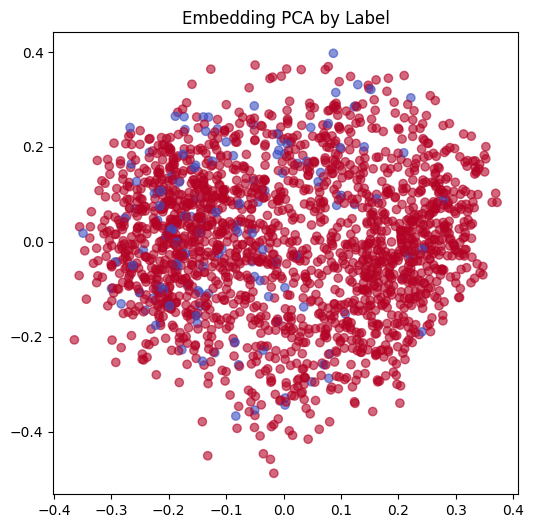

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Embedding PCA by Label")
plt.show()
